# Ghana Cocoa Yield Fuzzy Time-Series Forecasting

This notebook is the single working notebook for the study. It prepares the verified Ghana cocoa yield dataset, displays the data audit and exploratory figures, builds the rolling-origin validation framework, and visualizes the baseline, adaptive interval, high-order Chen FTS, and robustness analysis outputs.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "ghana_cocoa_yield_1961_2024.csv"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
MODEL_OUTPUTS_DIR = PROJECT_ROOT / "results" / "model_outputs"

PROJECT_ROOT


WindowsPath('E:/automations/Fuzzy')

## Regenerate Study Artifacts

Run this cell when you want the notebook to refresh the local dataset, audit tables, figures, validation framework, current modeling outputs, and sensitivity analysis from the project scripts.


In [2]:
from src.data import run as prepare_dataset
from src.exploration import run as build_exploration_outputs
from src.validation import run as build_validation_framework
from src.modeling import run as run_modeling_pipeline
from src.sensitivity import run as run_sensitivity_analysis

prepare_dataset()
build_exploration_outputs()
build_validation_framework()
run_modeling_pipeline()
run_sensitivity_analysis()


Dataset preparation complete.
Raw CSV: E:\automations\Fuzzy\data\raw\cocoa-bean-yields.csv
Processed CSV: E:\automations\Fuzzy\data\processed\ghana_cocoa_yield_1961_2024.csv
Data card: E:\automations\Fuzzy\data\DATA_CARD.md
Integrity report: E:\automations\Fuzzy\results\tables\data_integrity_report.csv


Data audit and exploratory analysis complete.
Data audit: E:\automations\Fuzzy\results\tables\data_audit.csv
Exploratory high-volatility years: E:\automations\Fuzzy\results\tables\exploratory_high_volatility_years.csv
Figures: E:\automations\Fuzzy\results\figures
Results README: E:\automations\Fuzzy\results\README.md
Validation framework complete.
Validation splits: E:\automations\Fuzzy\results\tables\validation_splits.csv
Metric definitions: E:\automations\Fuzzy\results\tables\metric_definitions.csv
Prediction template: E:\automations\Fuzzy\results\tables\rolling_predictions_template.csv
Framework checks: E:\automations\Fuzzy\results\tables\validation_framework_checks.csv


Modeling pipeline complete.
Model scenarios: E:\automations\Fuzzy\results\tables\model_scenarios.csv
Rolling predictions: E:\automations\Fuzzy\results\tables\rolling_predictions.csv
Overall metrics: E:\automations\Fuzzy\results\tables\overall_metrics.csv
Volatility metrics: E:\automations\Fuzzy\results\tables\volatility_metrics.csv
Interval strategy comparison: E:\automations\Fuzzy\results\tables\interval_strategy_comparison.csv
Rule order comparison: E:\automations\Fuzzy\results\tables\rule_order_comparison.csv
Forecast target comparison: E:\automations\Fuzzy\results\tables\forecast_target_comparison.csv
Fuzzy correction comparison: E:\automations\Fuzzy\results\tables\fuzzy_correction_comparison.csv
Fuzzy baseline gap analysis: E:\automations\Fuzzy\results\tables\fuzzy_baseline_gap_analysis.csv
Enhanced model recommendations: E:\automations\Fuzzy\results\tables\enhanced_model_recommendations.csv
Final-window interval boundaries: E:\automations\Fuzzy\results\model_outputs\equal_interva

Sensitivity analysis complete.
Sensitivity predictions: E:\automations\Fuzzy\results\tables\sensitivity_predictions.csv
Sensitivity metrics: E:\automations\Fuzzy\results\tables\sensitivity_metrics.csv
Sensitivity summary: E:\automations\Fuzzy\results\tables\sensitivity_summary.csv
Recommended model selection: E:\automations\Fuzzy\results\tables\recommended_model_selection.csv


## Load Study Tables

In [3]:
import pandas as pd

yield_data = pd.read_csv(DATA_PATH)
data_audit = pd.read_csv(TABLES_DIR / "data_audit.csv")
exploratory_high_volatility_years = pd.read_csv(TABLES_DIR / "exploratory_high_volatility_years.csv")
validation_splits = pd.read_csv(TABLES_DIR / "validation_splits.csv")
evaluation_high_volatility_years = pd.read_csv(TABLES_DIR / "evaluation_high_volatility_years.csv")
metric_definitions = pd.read_csv(TABLES_DIR / "metric_definitions.csv")
validation_checks = pd.read_csv(TABLES_DIR / "validation_framework_checks.csv")

model_scenarios = pd.read_csv(TABLES_DIR / "model_scenarios.csv")
rolling_predictions = pd.read_csv(TABLES_DIR / "rolling_predictions.csv")
overall_metrics = pd.read_csv(TABLES_DIR / "overall_metrics.csv")
volatility_metrics = pd.read_csv(TABLES_DIR / "volatility_metrics.csv")
equal_interval_boundaries = pd.read_csv(MODEL_OUTPUTS_DIR / "equal_interval_boundaries_final_window.csv")
equal_interval_rules = pd.read_csv(MODEL_OUTPUTS_DIR / "equal_interval_rules_final_window.csv")

interval_strategy_comparison = pd.read_csv(TABLES_DIR / "interval_strategy_comparison.csv")
rule_order_comparison = pd.read_csv(TABLES_DIR / "rule_order_comparison.csv")
adaptive_interval_boundaries = pd.read_csv(MODEL_OUTPUTS_DIR / "adaptive_interval_boundaries_final_window.csv")
adaptive_interval_rules = pd.read_csv(MODEL_OUTPUTS_DIR / "adaptive_interval_rules_final_window.csv")
high_order_rules = pd.read_csv(MODEL_OUTPUTS_DIR / "high_order_rules_final_window.csv")

forecast_target_comparison = pd.read_csv(TABLES_DIR / "forecast_target_comparison.csv")
fuzzy_correction_comparison = pd.read_csv(TABLES_DIR / "fuzzy_correction_comparison.csv")
fuzzy_baseline_gap_analysis = pd.read_csv(TABLES_DIR / "fuzzy_baseline_gap_analysis.csv")
enhanced_model_recommendations = pd.read_csv(TABLES_DIR / "enhanced_model_recommendations.csv")
change_interval_rules = pd.read_csv(MODEL_OUTPUTS_DIR / "change_interval_rules_final_window.csv")
percentage_change_interval_rules = pd.read_csv(MODEL_OUTPUTS_DIR / "percentage_change_interval_rules_final_window.csv")

display(yield_data.head())
display(yield_data.tail())
sensitivity_predictions = pd.read_csv(TABLES_DIR / "sensitivity_predictions.csv")
sensitivity_metrics = pd.read_csv(TABLES_DIR / "sensitivity_metrics.csv")
sensitivity_summary = pd.read_csv(TABLES_DIR / "sensitivity_summary.csv")
recommended_model_selection = pd.read_csv(TABLES_DIR / "recommended_model_selection.csv")


,year,yield_tonnes_per_hectare,yield_lag1,absolute_change,percentage_change,absolute_percentage_change,exploratory_high_volatility
0,1961,0.2364,NaN,NaN,NaN,NaN,False
1,1962,0.2378,0.2364,0.0014,0.592221,0.592221,False
2,1963,0.2351,0.2378,-0.0027,-1.135408,1.135408,False
3,1964,0.3141,0.2351,0.0790,33.602724,33.602724,True
4,1965,0.2272,0.3141,-0.0869,-27.666355,27.666355,True


,year,yield_tonnes_per_hectare,yield_lag1,absolute_change,percentage_change,absolute_percentage_change,exploratory_high_volatility
59,2020,0.5383,0.5282,0.0101,1.912156,1.912156,False
60,2021,0.5500,0.5383,0.0117,2.173502,2.173502,False
61,2022,0.5606,0.5500,0.0106,1.927273,1.927273,False
62,2023,0.5684,0.5606,0.0078,1.391366,1.391366,False
63,2024,0.5762,0.5684,0.0078,1.372285,1.372285,False


## Data Audit

In [4]:
data_audit

,metric,value
0,country,Ghana
1,commodity,cocoa beans
2,indicator,yield
3,unit,tonnes per hectare
4,frequency,annual
5,observation_count,64
6,first_year,1961
7,last_year,2024
8,missing_year_count,0
9,missing_years,none


In [5]:
audit_lookup = dict(zip(data_audit["metric"], data_audit["value"]))
summary = {
    "observation_count": audit_lookup["observation_count"],
    "year_range": f"{audit_lookup['first_year']}-{audit_lookup['last_year']}",
    "missing_year_count": audit_lookup["missing_year_count"],
    "missing_yield_values": audit_lookup["missing_yield_values"],
    "yield_min": audit_lookup["yield_min"],
    "yield_min_year": audit_lookup["yield_min_year"],
    "yield_max": audit_lookup["yield_max"],
    "yield_max_year": audit_lookup["yield_max_year"],
    "exploratory_high_volatility_threshold_percent": audit_lookup["absolute_annual_change_75th_percentile"],
    "exploratory_high_volatility_year_count": audit_lookup["exploratory_high_volatility_year_count"],
}

pd.DataFrame(summary.items(), columns=["item", "value"])

,item,value
0,observation_count,64
1,year_range,1961-2024
2,missing_year_count,0
3,missing_yield_values,0
4,yield_min,0.2054
5,yield_min_year,1981
6,yield_max,0.57620007
7,yield_max_year,2024
8,exploratory_high_volatility_threshold_percent,13.748883516429668
9,exploratory_high_volatility_year_count,16


## Exploratory High-Volatility Years

In [6]:
exploratory_high_volatility_years

,year,yield_tonnes_per_hectare,yield_lag1,absolute_change,percentage_change,absolute_percentage_change,exploratory_volatility_threshold
0,1988,0.3426,0.2545,0.0881,34.616904,34.616904,13.748884
1,1964,0.3141,0.2351,0.0790,33.602724,33.602724,13.748884
2,1992,0.4330,0.3354,0.0976,29.099584,29.099584,13.748884
3,1965,0.2272,0.3141,-0.0869,-27.666355,27.666355,13.748884
4,2012,0.5495,0.4374,0.1121,25.628727,25.628727,13.748884
5,1966,0.2823,0.2272,0.0551,24.251761,24.251761,13.748884
6,1989,0.4213,0.3426,0.0787,22.971388,22.971388,13.748884
7,1997,0.3000,0.3838,-0.0838,-21.834289,21.834289,13.748884
8,1991,0.3354,0.4232,-0.0878,-20.746695,20.746695,13.748884
9,2009,0.4441,0.3735,0.0706,18.902275,18.902275,13.748884


## Exploratory Figures

yield_timeseries.png


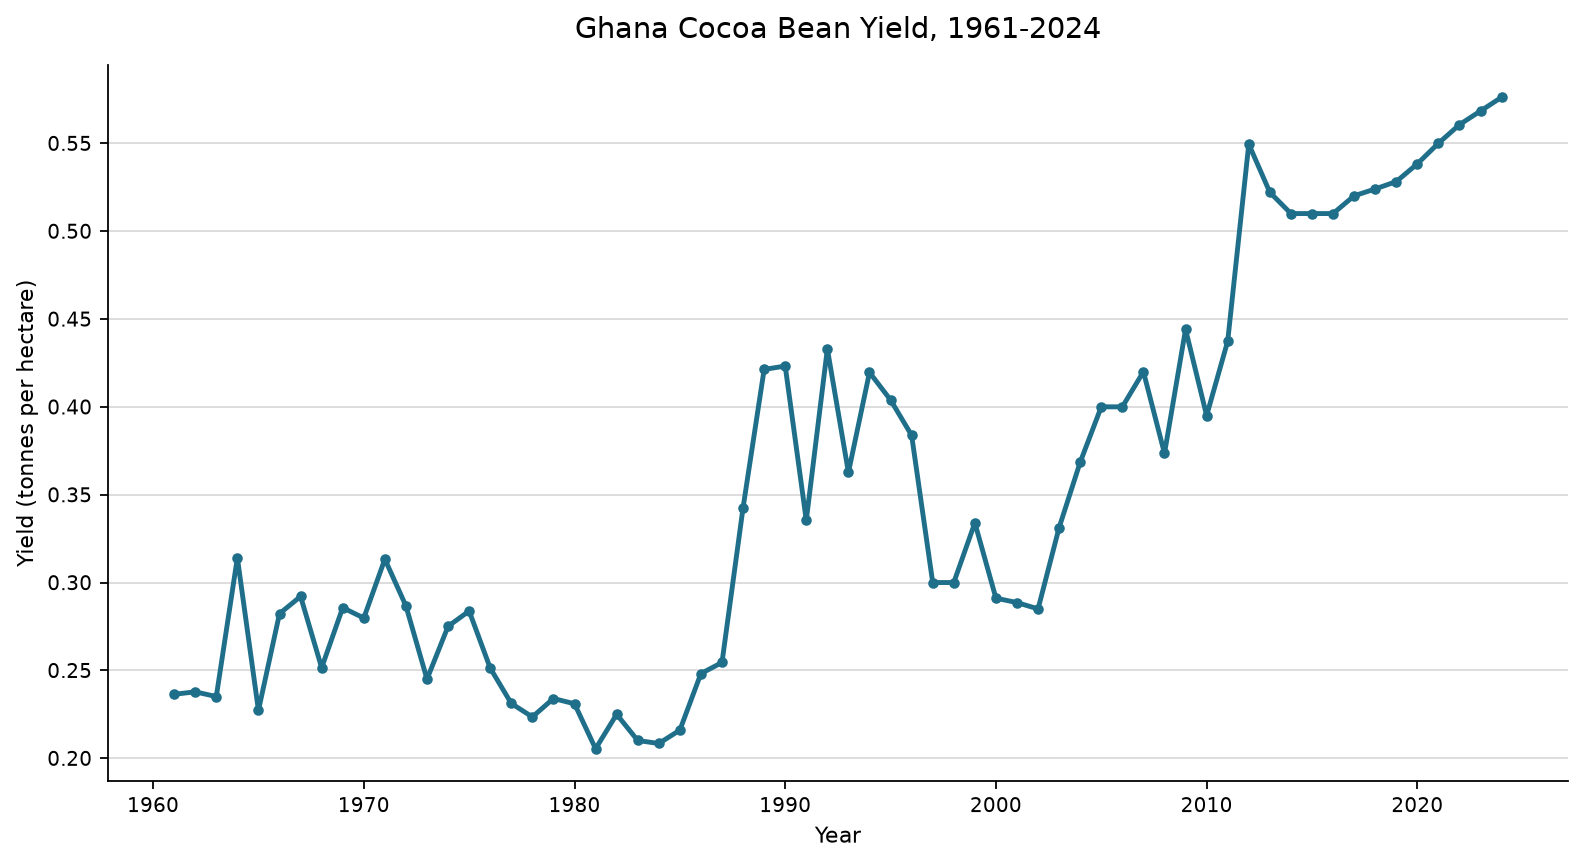

yield_pct_change.png


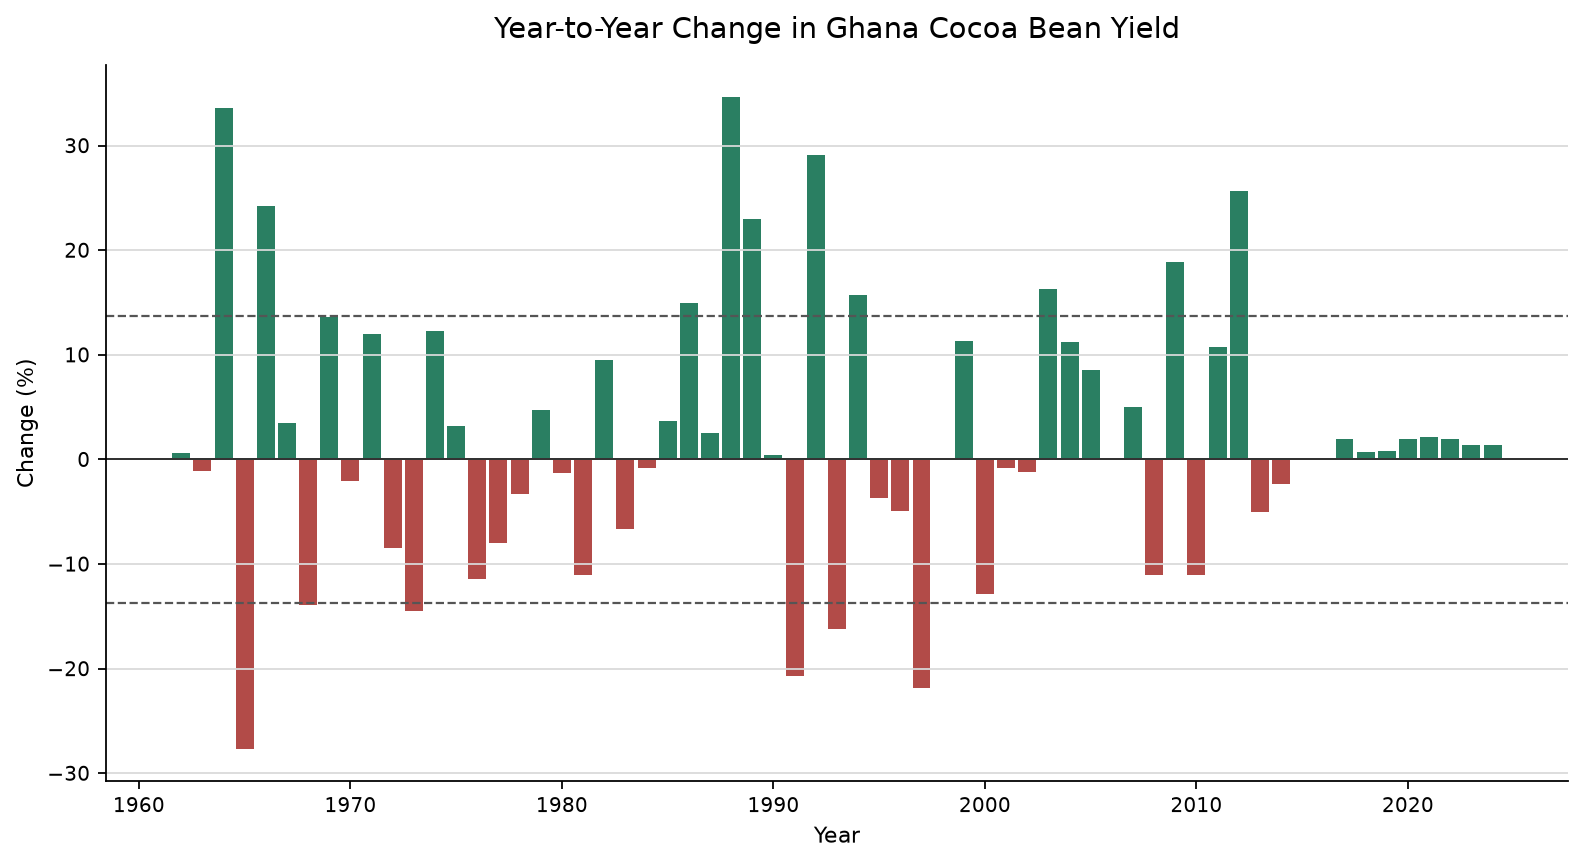

exploratory_high_volatility_years.png


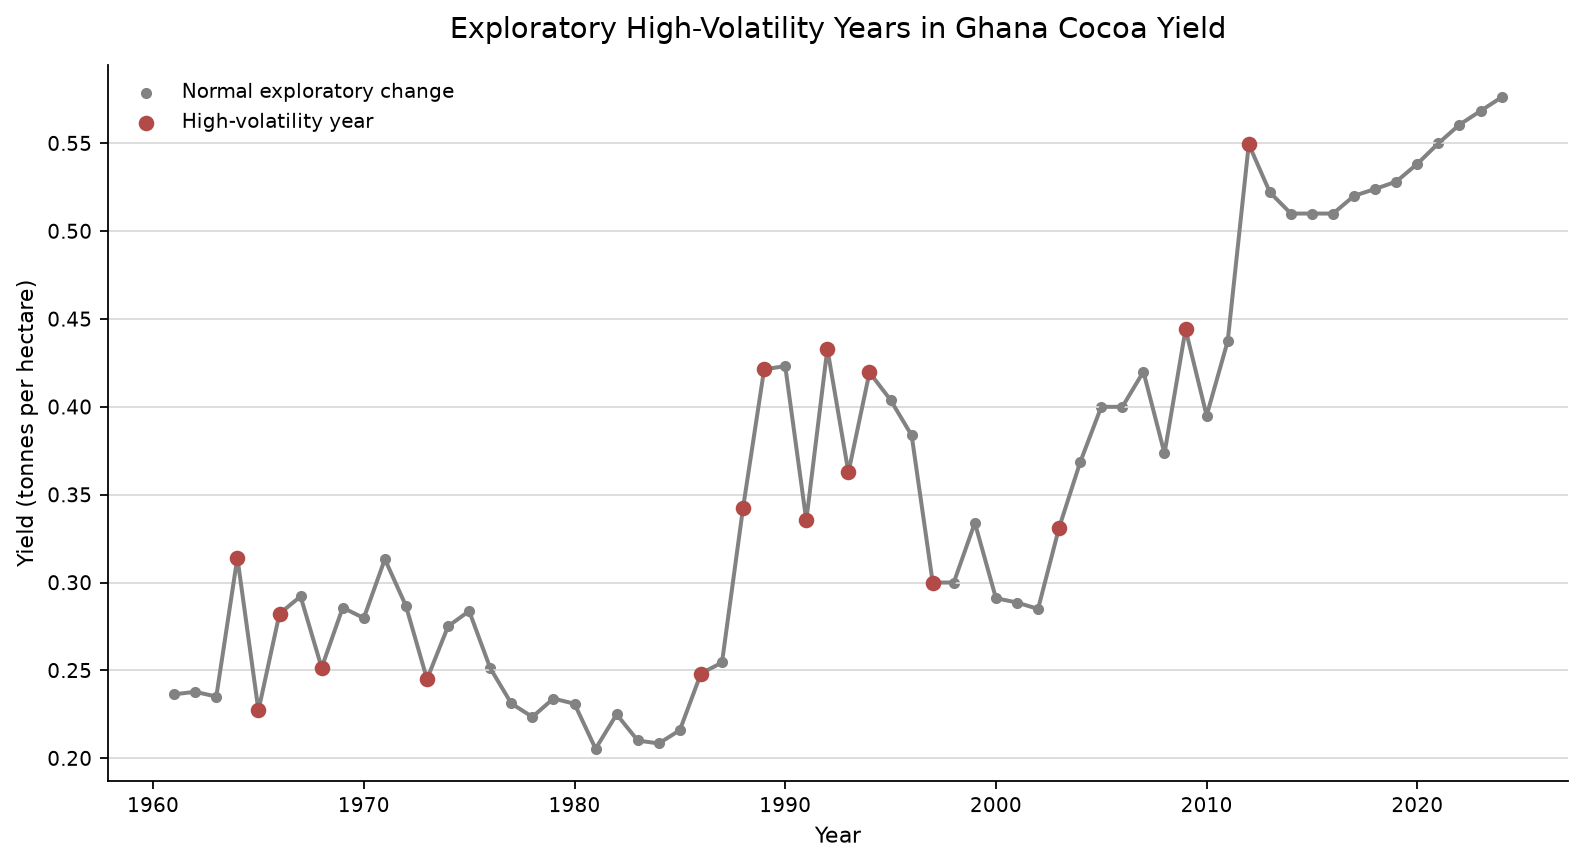

yield_change_distribution.png


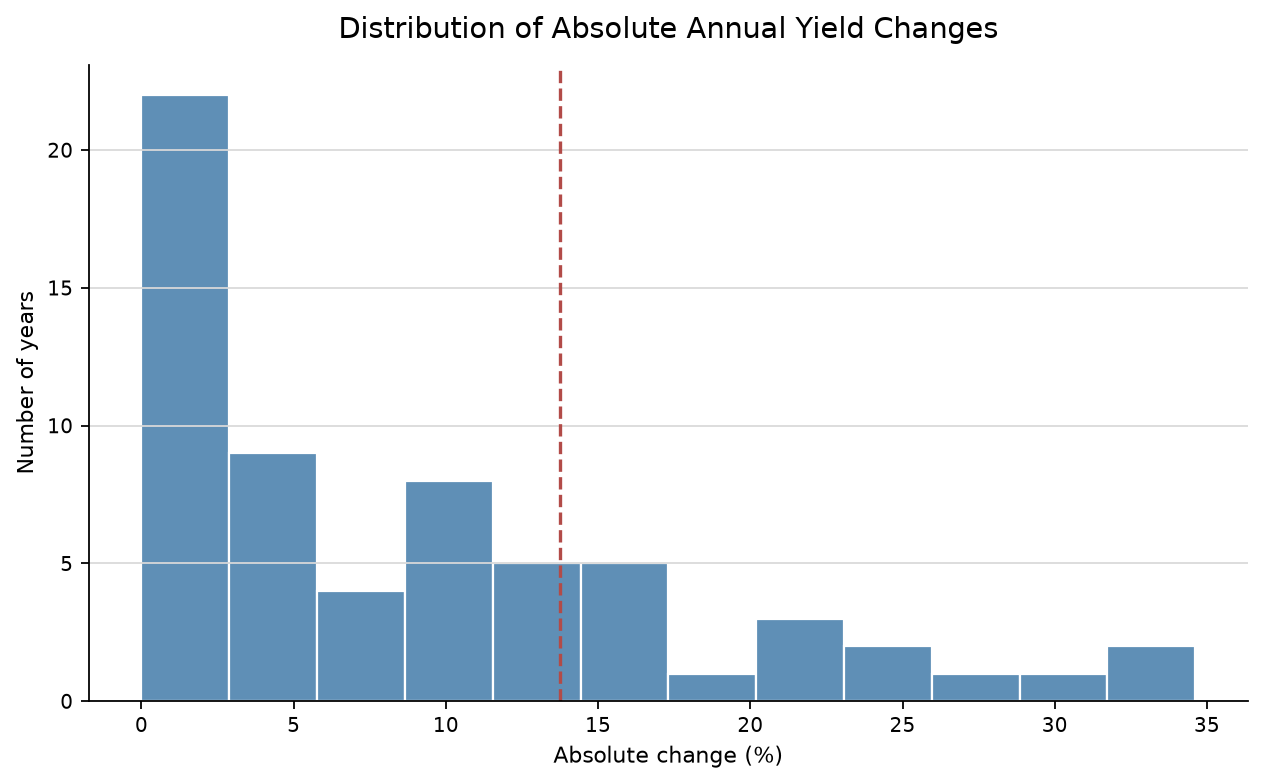

In [7]:
from IPython.display import Image, display

for figure_name in [
    "yield_timeseries.png",
    "yield_pct_change.png",
    "exploratory_high_volatility_years.png",
    "yield_change_distribution.png",
]:
    print(figure_name)
    display(Image(filename=str(FIGURES_DIR / figure_name)))

## Rolling-Origin Validation Framework

In [8]:
display(validation_splits.head())
display(validation_splits.tail())

,split_id,train_start_year,train_end_year,forecast_year,train_observation_count,forecast_horizon,actual_yield,previous_yield,actual_change,actual_percentage_change,absolute_actual_percentage_change,mase_scale,evaluation_volatility_threshold,is_evaluation_high_volatility
0,1,1961,1990,1991,30,1,0.3354,0.4232,-0.0878,-20.746695,20.746695,0.027814,12.466566,True
1,2,1961,1991,1992,31,1,0.4330,0.3354,0.0976,29.099584,29.099584,0.029813,12.466566,True
2,3,1961,1992,1993,32,1,0.3627,0.4330,-0.0703,-16.235567,16.235567,0.032000,12.466566,True
3,4,1961,1993,1994,33,1,0.4196,0.3627,0.0569,15.687901,15.687901,0.033197,12.466566,True
4,5,1961,1994,1995,34,1,0.4039,0.4196,-0.0157,-3.741661,3.741661,0.033915,12.466566,False


,split_id,train_start_year,train_end_year,forecast_year,train_observation_count,forecast_horizon,actual_yield,previous_yield,actual_change,actual_percentage_change,absolute_actual_percentage_change,mase_scale,evaluation_volatility_threshold,is_evaluation_high_volatility
29,30,1961,2019,2020,59,1,0.5383,0.5282,0.0101,1.912156,1.912156,0.031641,12.466566,False
30,31,1961,2020,2021,60,1,0.5500,0.5383,0.0117,2.173502,2.173502,0.031276,12.466566,False
31,32,1961,2021,2022,61,1,0.5606,0.5500,0.0106,1.927273,1.927273,0.030950,12.466566,False
32,33,1961,2022,2023,62,1,0.5684,0.5606,0.0078,1.391366,1.391366,0.030616,12.466566,False
33,34,1961,2023,2024,63,1,0.5762,0.5684,0.0078,1.372285,1.372285,0.030248,12.466566,False


In [9]:
validation_summary = {
    "split_count": len(validation_splits),
    "first_forecast_year": int(validation_splits["forecast_year"].min()),
    "last_forecast_year": int(validation_splits["forecast_year"].max()),
    "initial_training_observations": int(validation_splits["train_observation_count"].min()),
    "final_training_observations": int(validation_splits["train_observation_count"].max()),
    "evaluation_high_volatility_threshold_percent": validation_splits["evaluation_volatility_threshold"].iloc[0],
    "evaluation_high_volatility_year_count": int(validation_splits["is_evaluation_high_volatility"].sum()),
}

pd.DataFrame(validation_summary.items(), columns=["item", "value"])

,item,value
0,split_count,34.000000
1,first_forecast_year,1991.000000
2,last_forecast_year,2024.000000
3,initial_training_observations,30.000000
4,final_training_observations,63.000000
5,evaluation_high_volatility_threshold_percent,12.466566
6,evaluation_high_volatility_year_count,9.000000


## Evaluation-Period High-Volatility Years

In [10]:
evaluation_high_volatility_years

,forecast_year,actual_yield,previous_yield,actual_change,actual_percentage_change,absolute_actual_percentage_change,evaluation_volatility_threshold
0,1992,0.4330,0.3354,0.0976,29.099584,29.099584,12.466566
1,2012,0.5495,0.4374,0.1121,25.628727,25.628727,12.466566
2,1997,0.3000,0.3838,-0.0838,-21.834289,21.834289,12.466566
3,1991,0.3354,0.4232,-0.0878,-20.746695,20.746695,12.466566
4,2009,0.4441,0.3735,0.0706,18.902275,18.902275,12.466566
5,2003,0.3313,0.2850,0.0463,16.245602,16.245602,12.466566
6,1993,0.3627,0.4330,-0.0703,-16.235567,16.235567,12.466566
7,1994,0.4196,0.3627,0.0569,15.687901,15.687901,12.466566
8,2000,0.2911,0.3340,-0.0429,-12.844308,12.844308,12.466566


## Forecast Metrics

In [11]:
metric_definitions

,metric,name,formula,interpretation
0,mae,Mean Absolute Error,mean(abs(actual - forecast)),Lower is better; same unit as yield.
1,rmse,Root Mean Squared Error,sqrt(mean((actual - forecast)^2)),Lower is better; penalizes larger errors more ...
2,smape,Symmetric Mean Absolute Percentage Error,mean(200 * abs(actual - forecast) / (abs(actua...,Lower is better; percentage-style scale.
3,mase,Mean Absolute Scaled Error,mean(abs(actual - forecast) / in-sample naive ...,Values below 1 indicate improvement over the i...


## Framework Checks

In [12]:
validation_checks

,check_group,check,expected,observed,passed
0,metrics,mae_known_values,1.000000,1.000000,True
1,metrics,rmse_known_values,1.290994,1.290994,True
2,metrics,smape_known_values,35.555556,35.555556,True
3,metrics,mase_known_values,0.500000,0.500000,True
4,validation_splits,synthetic_split_count,3.000000,3.000000,True
5,validation_splits,first_forecast_year,2003.000000,2003.000000,True
6,validation_splits,first_train_end_year,2002.000000,2002.000000,True


## Modeling Notes

- All model runs use the same rolling-origin validation splits.
- ARIMA order selection is repeated inside each rolling training window.
- Equal-interval Chen FTS intervals and rules are rebuilt inside each rolling training window.
- Adaptive intervals and high-order fuzzy rules remain the next modeling extensions.


## Model Scenarios


In [13]:
model_scenarios


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,description,forecast_target,correction_weight,anchor_model_id
0,baseline_naive,Naive,baseline,none,NaN,NaN,previous_observation,One-step forecast equal to the latest training...,yield_level,NaN,NaN
1,baseline_mean,Mean,baseline,none,NaN,NaN,expanding_window_mean,One-step forecast equal to the expanding train...,yield_level,NaN,NaN
2,baseline_drift,Drift,baseline,none,NaN,NaN,one_step_linear_drift,One-step forecast using the linear change from...,yield_level,NaN,NaN
3,baseline_arima_aic,ARIMA-AIC,baseline,none,NaN,NaN,aic_grid_p0-2_d0-1_q0-2,ARIMA order selected by AIC inside each rollin...,yield_level,NaN,NaN
4,chen_equal_k5,Chen FTS Equal Intervals k=5,fuzzy_time_series,equal_length,1.0,5.0,k=5;margin_fraction=0.05;fuzzy_order=1;defuzzi...,First-order Chen fuzzy time series with equal-...,yield_level,NaN,NaN
5,chen_equal_k7,Chen FTS Equal Intervals k=7,fuzzy_time_series,equal_length,1.0,7.0,k=7;margin_fraction=0.05;fuzzy_order=1;defuzzi...,First-order Chen fuzzy time series with equal-...,yield_level,NaN,NaN
6,chen_equal_k9,Chen FTS Equal Intervals k=9,fuzzy_time_series,equal_length,1.0,9.0,k=9;margin_fraction=0.05;fuzzy_order=1;defuzzi...,First-order Chen fuzzy time series with equal-...,yield_level,NaN,NaN
7,chen_equal_k11,Chen FTS Equal Intervals k=11,fuzzy_time_series,equal_length,1.0,11.0,k=11;margin_fraction=0.05;fuzzy_order=1;defuzz...,First-order Chen fuzzy time series with equal-...,yield_level,NaN,NaN
8,chen_adaptive_k5,Chen FTS Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,1.0,5.0,k=5;quantiles=training_window;fuzzy_order=1;de...,First-order Chen fuzzy time series with quanti...,yield_level,NaN,NaN
9,chen_adaptive_k7,Chen FTS Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,1.0,7.0,k=7;quantiles=training_window;fuzzy_order=1;de...,First-order Chen fuzzy time series with quanti...,yield_level,NaN,NaN


## Rolling Forecast Predictions


In [14]:
display(rolling_predictions.head(16))

prediction_summary = {
    "prediction_rows": len(rolling_predictions),
    "validation_splits": rolling_predictions["split_id"].nunique(),
    "model_count": rolling_predictions["model_id"].nunique(),
    "models_per_split": rolling_predictions.groupby("split_id")["model_id"].nunique().unique().tolist(),
    "finite_forecasts": rolling_predictions["forecast_yield"].notna().all(),
}

pd.DataFrame(prediction_summary.items(), columns=["item", "value"])


,split_id,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,...,train_start_year,train_end_year,forecast_year,actual_yield,forecast_yield,forecast_error,absolute_error,squared_error,mase_scale,is_evaluation_high_volatility
0,1,baseline_naive,Naive,baseline,none,NaN,NaN,previous_observation,yield_level,NaN,...,1961,1990,1991,0.3354,0.423200,-0.087800,0.087800,0.007709,0.027814,True
1,1,baseline_mean,Mean,baseline,none,NaN,NaN,expanding_window_mean,yield_level,NaN,...,1961,1990,1991,0.3354,0.265720,0.069680,0.069680,0.004855,0.027814,True
2,1,baseline_drift,Drift,baseline,none,NaN,NaN,one_step_linear_drift,yield_level,NaN,...,1961,1990,1991,0.3354,0.429641,-0.094241,0.094241,0.008881,0.027814,True
3,1,baseline_arima_aic,ARIMA-AIC,baseline,none,NaN,NaN,aic_grid_p0-2_d0-1_q0-2,yield_level,NaN,...,1961,1990,1991,0.3354,0.407783,-0.072383,0.072383,0.005239,0.027814,True
4,1,chen_equal_k5,Chen FTS Equal Intervals k=5,fuzzy_time_series,equal_length,1.0,5.0,k=5;margin_fraction=0.05;fuzzy_order=1;defuzzi...,yield_level,NaN,...,1961,1990,1991,0.3354,0.410132,-0.074732,0.074732,0.005585,0.027814,True
5,1,chen_equal_k7,Chen FTS Equal Intervals k=7,fuzzy_time_series,equal_length,1.0,7.0,k=7;margin_fraction=0.05;fuzzy_order=1;defuzzi...,yield_level,NaN,...,1961,1990,1991,0.3354,0.416977,-0.081577,0.081577,0.006655,0.027814,True
6,1,chen_equal_k9,Chen FTS Equal Intervals k=9,fuzzy_time_series,equal_length,1.0,9.0,k=9;margin_fraction=0.05;fuzzy_order=1;defuzzi...,yield_level,NaN,...,1961,1990,1991,0.3354,0.420780,-0.085380,0.085380,0.007290,0.027814,True
7,1,chen_equal_k11,Chen FTS Equal Intervals k=11,fuzzy_time_series,equal_length,1.0,11.0,k=11;margin_fraction=0.05;fuzzy_order=1;defuzz...,yield_level,NaN,...,1961,1990,1991,0.3354,0.423200,-0.087800,0.087800,0.007709,0.027814,True
8,1,chen_adaptive_k5,Chen FTS Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,1.0,5.0,k=5;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,...,1961,1990,1991,0.3354,0.293646,0.041754,0.041754,0.001743,0.027814,True
9,1,chen_adaptive_k7,Chen FTS Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,1.0,7.0,k=7;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,...,1961,1990,1991,0.3354,0.314538,0.020863,0.020863,0.000435,0.027814,True


,item,value
0,prediction_rows,1632
1,validation_splits,34
2,model_count,48
3,models_per_split,[48]
4,finite_forecasts,True


## Overall Model Metrics


In [15]:
overall_metrics


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
0,chen_change_adaptive_k9_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,1.0,baseline_naive,0.029493,0.041516,7.595734,0.923749,34,1,4,1,1
1,chen_change_equal_k7_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,0.5,baseline_naive,0.029618,0.041226,7.631274,0.924265,34,2,2,2,2
2,chen_change_adaptive_k9_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,0.5,baseline_naive,0.029920,0.041076,7.666711,0.936798,34,3,1,3,3
3,chen_change_equal_k5_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,1.0,baseline_naive,0.030108,0.042973,7.770985,0.937241,34,4,11,5,4
4,chen_change_equal_k7_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,1.0,baseline_naive,0.030409,0.042655,7.850042,0.941939,34,5,10,7,5
5,chen_change_adaptive_k11_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,0.5,baseline_naive,0.030470,0.041400,7.735690,0.954396,34,6,3,4,7
6,chen_change_equal_k5_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,0.5,baseline_naive,0.030472,0.042641,7.792256,0.951005,34,7,9,6,6
7,chen_pct_change_adaptive_k5_w050,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,0.5,baseline_naive,0.030854,0.042086,7.899240,0.961775,34,8,5,8,8
8,chen_pct_change_adaptive_k5_w100,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,1.0,baseline_naive,0.031098,0.042493,7.981755,0.965748,34,9,6,11,9
9,chen_pct_change_adaptive_k9_w050,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=percentage_change;k=9;correcti...,percentage_change,0.5,baseline_naive,0.031245,0.043918,7.941145,0.976412,34,10,14,9,10


## Volatility-Specific Metrics


In [16]:
display(volatility_metrics.loc[volatility_metrics["is_evaluation_high_volatility"]].reset_index(drop=True))
display(volatility_metrics.loc[~volatility_metrics["is_evaluation_high_volatility"]].reset_index(drop=True))


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,is_evaluation_high_volatility,mae,rmse,smape,mase,forecast_count
0,chen_adaptive_k9,Chen FTS Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,1.0,9.0,k=9;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,True,0.056440,0.075632,14.269970,1.745225,9
1,chen_equal_k7,Chen FTS Equal Intervals k=7,fuzzy_time_series,equal_length,1.0,7.0,k=7;margin_fraction=0.05;fuzzy_order=1;defuzzi...,yield_level,NaN,NaN,True,0.056934,0.075743,14.655473,1.788819,9
2,chen_change_adaptive_k9_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,1.0,baseline_naive,True,0.057350,0.067316,14.638405,1.842643,9
3,chen_pct_change_adaptive_k5_w100,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,1.0,baseline_naive,True,0.058961,0.068870,15.126231,1.875688,9
4,chen_change_adaptive_k11_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,1.0,baseline_naive,True,0.059259,0.069972,15.041583,1.901487,9
5,chen_change_equal_k7_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,1.0,baseline_naive,True,0.061306,0.068722,15.650845,1.946171,9
6,chen_change_adaptive_k7_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,1.0,baseline_naive,True,0.062602,0.072020,16.139206,2.000333,9
7,chen_order2_adaptive_k5,Chen FTS Order 2 Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,2.0,5.0,k=5;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,True,0.062651,0.078206,16.627629,1.946616,9
8,chen_pct_change_equal_k5_w100,Chen FTS Percentage Change Correction Equal In...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,1.0,baseline_naive,True,0.064444,0.073541,16.515508,2.035742,9
9,chen_change_equal_k5_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,1.0,baseline_naive,True,0.064930,0.072020,16.659866,2.063724,9


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,is_evaluation_high_volatility,mae,rmse,smape,mase,forecast_count
0,baseline_drift,Drift,baseline,none,NaN,NaN,one_step_linear_drift,yield_level,NaN,NaN,False,0.016245,0.022835,3.964831,0.493010,25
1,baseline_naive,Naive,baseline,none,NaN,NaN,previous_observation,yield_level,NaN,NaN,False,0.016332,0.022341,3.949622,0.499248,25
2,chen_change_equal_k7_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,0.5,baseline_naive,False,0.016713,0.021991,4.305012,0.508385,25
3,chen_change_equal_k5_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,0.5,baseline_naive,False,0.016756,0.022852,4.223925,0.509551,25
4,chen_change_adaptive_k9_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,0.5,baseline_naive,False,0.017002,0.022037,4.330482,0.518960,25
5,chen_change_equal_k5_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,1.0,baseline_naive,False,0.017572,0.025381,4.570988,0.531708,25
6,chen_pct_change_adaptive_k9_w050,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=percentage_change;k=9;correcti...,percentage_change,0.5,baseline_naive,False,0.017665,0.022949,4.435891,0.535914,25
7,chen_pct_change_adaptive_k5_w050,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,0.5,baseline_naive,False,0.017982,0.023361,4.561472,0.546980,25
8,chen_change_adaptive_k11_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,0.5,baseline_naive,False,0.018019,0.022024,4.504608,0.550756,25
9,chen_pct_change_equal_k7_w050,Chen FTS Percentage Change Correction Equal In...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=percentage_change;k=7;correcti...,percentage_change,0.5,baseline_naive,False,0.018267,0.025482,4.682118,0.552790,25


## Equal-Interval Chen FTS Final Window


In [17]:
display(equal_interval_boundaries.head(16))
display(equal_interval_rules.head(16))


,model_id,interval_count,train_start_year,train_end_year,interval_id,state,lower_bound,upper_bound,midpoint,is_final_interval,interval_strategy,requested_interval_count,effective_interval_count,duplicate_boundary_count,margin_fraction
0,chen_equal_k5,5,1961,2023,1,A1,0.187250,0.267110,0.227180,False,equal_length,5,5,0,0.05
1,chen_equal_k5,5,1961,2023,2,A2,0.267110,0.346970,0.307040,False,equal_length,5,5,0,0.05
2,chen_equal_k5,5,1961,2023,3,A3,0.346970,0.426830,0.386900,False,equal_length,5,5,0,0.05
3,chen_equal_k5,5,1961,2023,4,A4,0.426830,0.506690,0.466760,False,equal_length,5,5,0,0.05
4,chen_equal_k5,5,1961,2023,5,A5,0.506690,0.586550,0.546620,True,equal_length,5,5,0,0.05
5,chen_equal_k7,7,1961,2023,1,A1,0.187250,0.244293,0.215771,False,equal_length,7,7,0,0.05
6,chen_equal_k7,7,1961,2023,2,A2,0.244293,0.301336,0.272814,False,equal_length,7,7,0,0.05
7,chen_equal_k7,7,1961,2023,3,A3,0.301336,0.358379,0.329857,False,equal_length,7,7,0,0.05
8,chen_equal_k7,7,1961,2023,4,A4,0.358379,0.415421,0.386900,False,equal_length,7,7,0,0.05
9,chen_equal_k7,7,1961,2023,5,A5,0.415421,0.472464,0.443943,False,equal_length,7,7,0,0.05


,model_id,interval_count,train_start_year,train_end_year,antecedent_state,consequent_states,consequent_counts,transition_count,forecast_yield,defuzzification
0,chen_equal_k5,5,1961,2023,A1,A1;A2,A1:13;A2:5,18,0.249363,frequency_weighted_midpoint
1,chen_equal_k5,5,1961,2023,A2,A2;A1;A3;A4,A2:11;A1:4;A3:2;A4:1,18,0.307040,frequency_weighted_midpoint
2,chen_equal_k5,5,1961,2023,A3,A3;A2;A4,A3:8;A2:2;A4:2,12,0.386900,frequency_weighted_midpoint
3,chen_equal_k5,5,1961,2023,A4,A3;A5,A3:2;A5:1,3,0.440140,frequency_weighted_midpoint
4,chen_equal_k5,5,1961,2023,A5,A5,A5:11,11,0.546620,frequency_weighted_midpoint
5,chen_equal_k7,7,1961,2023,A1,A1;A2;A3,A1:10;A2:2;A3:1,13,0.233323,frequency_weighted_midpoint
6,chen_equal_k7,7,1961,2023,A2,A2;A3;A1,A2:12;A3:4;A1:1,17,0.282881,frequency_weighted_midpoint
7,chen_equal_k7,7,1961,2023,A3,A2;A5;A1;A4,A2:2;A5:2;A1:1;A4:1,6,0.339364,frequency_weighted_midpoint
8,chen_equal_k7,7,1961,2023,A4,A5;A4;A2,A5:4;A4:3;A2:1,8,0.401161,frequency_weighted_midpoint
9,chen_equal_k7,7,1961,2023,A5,A4;A3;A5;A7,A4:4;A3:1;A5:1;A7:1,7,0.411347,frequency_weighted_midpoint


## Current Modeling Summary


In [18]:
best_overall_mae = overall_metrics.sort_values("mae").iloc[0]
best_high_volatility_mae = (
    volatility_metrics
    .loc[volatility_metrics["is_evaluation_high_volatility"]]
    .sort_values("mae")
    .iloc[0]
)

pd.DataFrame(
    [
        {
            "evaluation_view": "overall",
            "selection_metric": "mae",
            "best_model_id": best_overall_mae["model_id"],
            "mae": best_overall_mae["mae"],
            "rmse": best_overall_mae["rmse"],
            "smape": best_overall_mae["smape"],
            "mase": best_overall_mae["mase"],
        },
        {
            "evaluation_view": "high_volatility",
            "selection_metric": "mae",
            "best_model_id": best_high_volatility_mae["model_id"],
            "mae": best_high_volatility_mae["mae"],
            "rmse": best_high_volatility_mae["rmse"],
            "smape": best_high_volatility_mae["smape"],
            "mase": best_high_volatility_mae["mase"],
        },
    ]
)


,evaluation_view,selection_metric,best_model_id,mae,rmse,smape,mase
0,overall,mae,chen_change_adaptive_k9_w100,0.029493,0.041516,7.595734,0.923749
1,high_volatility,mae,chen_adaptive_k9,0.056440,0.075632,14.269970,1.745225


## Adaptive Interval Results


In [19]:
adaptive_model_ids = [model_id for model_id in model_scenarios["model_id"] if model_id.startswith("chen_adaptive_")]

display(model_scenarios.loc[model_scenarios["model_id"].isin(adaptive_model_ids)])
display(overall_metrics.loc[overall_metrics["model_id"].isin(adaptive_model_ids)].sort_values("mae"))
display(
    volatility_metrics
    .loc[
        volatility_metrics["is_evaluation_high_volatility"]
        & volatility_metrics["model_id"].isin(adaptive_model_ids)
    ]
    .sort_values("mae")
)


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,description,forecast_target,correction_weight,anchor_model_id
8,chen_adaptive_k5,Chen FTS Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,1.0,5.0,k=5;quantiles=training_window;fuzzy_order=1;de...,First-order Chen fuzzy time series with quanti...,yield_level,NaN,NaN
9,chen_adaptive_k7,Chen FTS Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,1.0,7.0,k=7;quantiles=training_window;fuzzy_order=1;de...,First-order Chen fuzzy time series with quanti...,yield_level,NaN,NaN
10,chen_adaptive_k9,Chen FTS Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,1.0,9.0,k=9;quantiles=training_window;fuzzy_order=1;de...,First-order Chen fuzzy time series with quanti...,yield_level,NaN,NaN
11,chen_adaptive_k11,Chen FTS Adaptive Intervals k=11,fuzzy_time_series,adaptive_quantile,1.0,11.0,k=11;quantiles=training_window;fuzzy_order=1;d...,First-order Chen fuzzy time series with quanti...,yield_level,NaN,NaN


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
39,chen_adaptive_k9,Chen FTS Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,1.0,9.0,k=9;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,0.044877,0.056496,10.993266,1.365546,34,40,37,40,40
41,chen_adaptive_k11,Chen FTS Adaptive Intervals k=11,fuzzy_time_series,adaptive_quantile,1.0,11.0,k=11;quantiles=training_window;fuzzy_order=1;d...,yield_level,NaN,NaN,0.045697,0.061767,11.584746,1.404455,34,42,42,42,41
43,chen_adaptive_k7,Chen FTS Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,1.0,7.0,k=7;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,0.050689,0.060715,12.280484,1.548298,34,44,40,44,44
45,chen_adaptive_k5,Chen FTS Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,1.0,5.0,k=5;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,0.059117,0.069940,13.965314,1.826544,34,46,46,46,47


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,is_evaluation_high_volatility,mae,rmse,smape,mase,forecast_count
0,chen_adaptive_k9,Chen FTS Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,1.0,9.0,k=9;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,True,0.056440,0.075632,14.269970,1.745225,9
16,chen_adaptive_k7,Chen FTS Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,1.0,7.0,k=7;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,True,0.066725,0.079313,17.474174,2.071723,9
18,chen_adaptive_k5,Chen FTS Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,1.0,5.0,k=5;quantiles=training_window;fuzzy_order=1;de...,yield_level,NaN,NaN,True,0.067774,0.081458,17.778146,2.131998,9
29,chen_adaptive_k11,Chen FTS Adaptive Intervals k=11,fuzzy_time_series,adaptive_quantile,1.0,11.0,k=11;quantiles=training_window;fuzzy_order=1;d...,yield_level,NaN,NaN,True,0.070949,0.093375,18.961744,2.232831,9


## High-Order Rule Results


In [20]:
high_order_model_ids = [model_id for model_id in model_scenarios["model_id"] if model_id.startswith("chen_order2_")]

display(model_scenarios.loc[model_scenarios["model_id"].isin(high_order_model_ids)])
display(overall_metrics.loc[overall_metrics["model_id"].isin(high_order_model_ids)].sort_values("mae"))
display(
    volatility_metrics
    .loc[
        volatility_metrics["is_evaluation_high_volatility"]
        & volatility_metrics["model_id"].isin(high_order_model_ids)
    ]
    .sort_values("mae")
)

display(
    rolling_predictions
    .loc[rolling_predictions["model_id"].isin(high_order_model_ids)]
    .groupby(["model_id", "fit_status"], as_index=False)
    .size()
    .rename(columns={"size": "split_count"})
)


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,description,forecast_target,correction_weight,anchor_model_id
12,chen_order2_adaptive_k5,Chen FTS Order 2 Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,2.0,5.0,k=5;quantiles=training_window;fuzzy_order=2;de...,Order-2 Chen fuzzy time series with quantile-b...,yield_level,NaN,NaN
13,chen_order2_adaptive_k7,Chen FTS Order 2 Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,2.0,7.0,k=7;quantiles=training_window;fuzzy_order=2;de...,Order-2 Chen fuzzy time series with quantile-b...,yield_level,NaN,NaN
14,chen_order2_adaptive_k9,Chen FTS Order 2 Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,2.0,9.0,k=9;quantiles=training_window;fuzzy_order=2;de...,Order-2 Chen fuzzy time series with quantile-b...,yield_level,NaN,NaN
15,chen_order2_adaptive_k11,Chen FTS Order 2 Adaptive Intervals k=11,fuzzy_time_series,adaptive_quantile,2.0,11.0,k=11;quantiles=training_window;fuzzy_order=2;d...,Order-2 Chen fuzzy time series with quantile-b...,yield_level,NaN,NaN


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
36,chen_order2_adaptive_k11,Chen FTS Order 2 Adaptive Intervals k=11,fuzzy_time_series,adaptive_quantile,2.0,11.0,k=11;quantiles=training_window;fuzzy_order=2;d...,yield_level,NaN,NaN,0.040666,0.058134,10.381807,1.254870,34,37,38,38,37
42,chen_order2_adaptive_k9,Chen FTS Order 2 Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,2.0,9.0,k=9;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,0.046644,0.063511,11.817847,1.427759,34,43,43,43,43
44,chen_order2_adaptive_k7,Chen FTS Order 2 Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,2.0,7.0,k=7;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,0.052893,0.064170,13.335376,1.609360,34,45,44,45,45
46,chen_order2_adaptive_k5,Chen FTS Order 2 Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,2.0,5.0,k=5;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,0.059501,0.070488,14.677680,1.820032,34,47,47,47,46


,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,correction_weight,anchor_model_id,is_evaluation_high_volatility,mae,rmse,smape,mase,forecast_count
7,chen_order2_adaptive_k5,Chen FTS Order 2 Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,2.0,5.0,k=5;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,True,0.062651,0.078206,16.627629,1.946616,9
13,chen_order2_adaptive_k7,Chen FTS Order 2 Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,2.0,7.0,k=7;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,True,0.065841,0.075412,17.176690,2.040296,9
24,chen_order2_adaptive_k11,Chen FTS Order 2 Adaptive Intervals k=11,fuzzy_time_series,adaptive_quantile,2.0,11.0,k=11;quantiles=training_window;fuzzy_order=2;d...,yield_level,NaN,NaN,True,0.069528,0.091960,18.435482,2.189851,9
31,chen_order2_adaptive_k9,Chen FTS Order 2 Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,2.0,9.0,k=9;quantiles=training_window;fuzzy_order=2;de...,yield_level,NaN,NaN,True,0.072928,0.094009,18.874935,2.258614,9


,model_id,fit_status,split_count
0,chen_order2_adaptive_k11,fallback_first_order,12
1,chen_order2_adaptive_k11,fitted,22
2,chen_order2_adaptive_k5,fitted,34
3,chen_order2_adaptive_k7,fallback_first_order,4
4,chen_order2_adaptive_k7,fitted,30
5,chen_order2_adaptive_k9,fallback_first_order,7
6,chen_order2_adaptive_k9,fitted,27


## Interval Strategy Comparison


In [21]:
display(interval_strategy_comparison)

display(
    interval_strategy_comparison
    .loc[interval_strategy_comparison["metric"].isin(["mae", "smape"])]
    .pivot_table(
        index=["evaluation_view", "interval_count"],
        columns="metric",
        values="right_improved",
        aggfunc="first",
    )
    .reset_index()
)


,evaluation_view,interval_count,metric,left_label,left_model_id,left_value,right_label,right_model_id,right_value,right_minus_left,right_improved
0,overall,5,mae,equal_length,chen_equal_k5,0.036874,adaptive_quantile,chen_adaptive_k5,0.059117,0.022243,False
1,overall,5,rmse,equal_length,chen_equal_k5,0.055635,adaptive_quantile,chen_adaptive_k5,0.069940,0.014305,False
2,overall,5,smape,equal_length,chen_equal_k5,9.481963,adaptive_quantile,chen_adaptive_k5,13.965314,4.483351,False
3,overall,5,mase,equal_length,chen_equal_k5,1.154026,adaptive_quantile,chen_adaptive_k5,1.826544,0.672518,False
4,overall,7,mae,equal_length,chen_equal_k7,0.036062,adaptive_quantile,chen_adaptive_k7,0.050689,0.014627,False
5,overall,7,rmse,equal_length,chen_equal_k7,0.048937,adaptive_quantile,chen_adaptive_k7,0.060715,0.011779,False
6,overall,7,smape,equal_length,chen_equal_k7,9.053856,adaptive_quantile,chen_adaptive_k7,12.280484,3.226627,False
7,overall,7,mase,equal_length,chen_equal_k7,1.114997,adaptive_quantile,chen_adaptive_k7,1.548298,0.433300,False
8,overall,9,mae,equal_length,chen_equal_k9,0.041825,adaptive_quantile,chen_adaptive_k9,0.044877,0.003052,False
9,overall,9,rmse,equal_length,chen_equal_k9,0.058667,adaptive_quantile,chen_adaptive_k9,0.056496,-0.002171,True


metric,evaluation_view,interval_count,mae,smape
0,high_volatility,5,True,True
1,high_volatility,7,False,False
2,high_volatility,9,True,True
3,high_volatility,11,False,False
4,overall,5,False,False
5,overall,7,False,False
6,overall,9,False,False
7,overall,11,False,False


## Rule-Order Comparison


In [22]:
display(rule_order_comparison)

display(
    rule_order_comparison
    .loc[rule_order_comparison["metric"].isin(["mae", "smape"])]
    .pivot_table(
        index=["evaluation_view", "interval_count"],
        columns="metric",
        values="right_improved",
        aggfunc="first",
    )
    .reset_index()
)


,evaluation_view,interval_count,metric,left_label,left_model_id,left_value,right_label,right_model_id,right_value,right_minus_left,right_improved
0,overall,5,mae,first_order,chen_adaptive_k5,0.059117,second_order,chen_order2_adaptive_k5,0.059501,0.000385,False
1,overall,5,rmse,first_order,chen_adaptive_k5,0.069940,second_order,chen_order2_adaptive_k5,0.070488,0.000548,False
2,overall,5,smape,first_order,chen_adaptive_k5,13.965314,second_order,chen_order2_adaptive_k5,14.677680,0.712367,False
3,overall,5,mase,first_order,chen_adaptive_k5,1.826544,second_order,chen_order2_adaptive_k5,1.820032,-0.006512,True
4,overall,7,mae,first_order,chen_adaptive_k7,0.050689,second_order,chen_order2_adaptive_k7,0.052893,0.002204,False
5,overall,7,rmse,first_order,chen_adaptive_k7,0.060715,second_order,chen_order2_adaptive_k7,0.064170,0.003455,False
6,overall,7,smape,first_order,chen_adaptive_k7,12.280484,second_order,chen_order2_adaptive_k7,13.335376,1.054892,False
7,overall,7,mase,first_order,chen_adaptive_k7,1.548298,second_order,chen_order2_adaptive_k7,1.609360,0.061062,False
8,overall,9,mae,first_order,chen_adaptive_k9,0.044877,second_order,chen_order2_adaptive_k9,0.046644,0.001767,False
9,overall,9,rmse,first_order,chen_adaptive_k9,0.056496,second_order,chen_order2_adaptive_k9,0.063511,0.007015,False


metric,evaluation_view,interval_count,mae,smape
0,high_volatility,5,True,True
1,high_volatility,7,True,True
2,high_volatility,9,False,False
3,high_volatility,11,True,True
4,overall,5,False,False
5,overall,7,False,False
6,overall,9,False,False
7,overall,11,True,True


## Adaptive And High-Order Final Window


In [23]:
display(adaptive_interval_boundaries.head(16))
display(adaptive_interval_rules.head(16))
display(high_order_rules.head(16))


,model_id,interval_count,train_start_year,train_end_year,interval_id,state,lower_bound,upper_bound,midpoint,is_final_interval,interval_strategy,requested_interval_count,effective_interval_count,duplicate_boundary_count,margin_fraction
0,chen_adaptive_k5,5,1961,2023,1,A1,0.205400,0.240680,0.223040,False,adaptive_quantile,5,5,0,NaN
1,chen_adaptive_k5,5,1961,2023,2,A2,0.240680,0.288220,0.264450,False,adaptive_quantile,5,5,0,NaN
2,chen_adaptive_k5,5,1961,2023,3,A3,0.288220,0.369500,0.328860,False,adaptive_quantile,5,5,0,NaN
3,chen_adaptive_k5,5,1961,2023,4,A4,0.369500,0.441420,0.405460,False,adaptive_quantile,5,5,0,NaN
4,chen_adaptive_k5,5,1961,2023,5,A5,0.441420,0.568400,0.504910,True,adaptive_quantile,5,5,0,NaN
5,chen_adaptive_k7,7,1961,2023,1,A1,0.205400,0.233600,0.219500,False,adaptive_quantile,7,7,0,NaN
6,chen_adaptive_k7,7,1961,2023,2,A2,0.233600,0.269214,0.251407,False,adaptive_quantile,7,7,0,NaN
7,chen_adaptive_k7,7,1961,2023,3,A3,0.269214,0.291671,0.280443,False,adaptive_quantile,7,7,0,NaN
8,chen_adaptive_k7,7,1961,2023,4,A4,0.291671,0.351214,0.321443,False,adaptive_quantile,7,7,0,NaN
9,chen_adaptive_k7,7,1961,2023,5,A5,0.351214,0.419714,0.385464,False,adaptive_quantile,7,7,0,NaN


,model_id,interval_count,train_start_year,train_end_year,antecedent_state,consequent_states,consequent_counts,transition_count,forecast_yield,defuzzification
0,chen_adaptive_k5,5,1961,2023,A1,A1;A2;A3,A1:10;A2:2;A3:1,13,0.237551,frequency_weighted_midpoint
1,chen_adaptive_k5,5,1961,2023,A2,A2;A3;A1,A2:7;A3:4;A1:1,12,0.282469,frequency_weighted_midpoint
2,chen_adaptive_k5,5,1961,2023,A3,A3;A4;A2;A1,A3:5;A4:4;A2:3;A1:1,13,0.329425,frequency_weighted_midpoint
3,chen_adaptive_k5,5,1961,2023,A4,A4;A3;A5,A4:7;A3:3;A5:2,12,0.402885,frequency_weighted_midpoint
4,chen_adaptive_k5,5,1961,2023,A5,A5;A4,A5:11;A4:1,12,0.496623,frequency_weighted_midpoint
5,chen_adaptive_k7,7,1961,2023,A1,A1;A2;A3,A1:6;A2:2;A3:1,9,0.233362,frequency_weighted_midpoint
6,chen_adaptive_k7,7,1961,2023,A2,A2;A1;A3;A4,A2:3;A1:2;A3:2;A4:2,9,0.266333,frequency_weighted_midpoint
7,chen_adaptive_k7,7,1961,2023,A3,A3;A4;A2,A3:4;A4:3;A2:2,9,0.287657,frequency_weighted_midpoint
8,chen_adaptive_k7,7,1961,2023,A4,A3;A4;A6;A1;A2;A5,A3:2;A4:2;A6:2;A1:1;A2:1;A5:1,9,0.332367,frequency_weighted_midpoint
9,chen_adaptive_k7,7,1961,2023,A5,A5;A6;A4,A5:5;A6:3;A4:1,9,0.405056,frequency_weighted_midpoint


,model_id,interval_count,train_start_year,train_end_year,antecedent_states,consequent_states,consequent_counts,transition_count,forecast_yield,defuzzification
0,chen_order2_adaptive_k5,5,1961,2023,"A1,A1",A1;A2;A3,A1:8;A2:1;A3:1,10,0.237763,frequency_weighted_midpoint
1,chen_order2_adaptive_k5,5,1961,2023,"A1,A2",A2;A3,A2:1;A3:1,2,0.296655,frequency_weighted_midpoint
2,chen_order2_adaptive_k5,5,1961,2023,"A1,A3",A1,A1:1,1,0.223040,frequency_weighted_midpoint
3,chen_order2_adaptive_k5,5,1961,2023,"A2,A1",A1,A1:1,1,0.223040,frequency_weighted_midpoint
4,chen_order2_adaptive_k5,5,1961,2023,"A2,A2",A2;A3;A1,A2:4;A3:2;A1:1,7,0.276937,frequency_weighted_midpoint
5,chen_order2_adaptive_k5,5,1961,2023,"A2,A3",A2;A3;A4,A2:2;A3:1;A4:1,4,0.315805,frequency_weighted_midpoint
6,chen_order2_adaptive_k5,5,1961,2023,"A3,A1",A2,A2:1,1,0.264450,frequency_weighted_midpoint
7,chen_order2_adaptive_k5,5,1961,2023,"A3,A2",A2;A3,A2:2;A3:1,3,0.285920,frequency_weighted_midpoint
8,chen_order2_adaptive_k5,5,1961,2023,"A3,A3",A3;A2;A4,A3:3;A2:1;A4:1,5,0.331298,frequency_weighted_midpoint
9,chen_order2_adaptive_k5,5,1961,2023,"A3,A4",A4;A3,A4:3;A3:1,4,0.386310,frequency_weighted_midpoint


## Expanded Modeling Summary


In [24]:
expanded_summary = {
    "prediction_rows": len(rolling_predictions),
    "validation_splits": rolling_predictions["split_id"].nunique(),
    "model_count": rolling_predictions["model_id"].nunique(),
    "expected_prediction_rows": rolling_predictions["split_id"].nunique() * rolling_predictions["model_id"].nunique(),
    "best_overall_mae_model": overall_metrics.sort_values("mae").iloc[0]["model_id"],
    "best_high_volatility_mae_model": (
        volatility_metrics
        .loc[volatility_metrics["is_evaluation_high_volatility"]]
        .sort_values("mae")
        .iloc[0]["model_id"]
    ),
    "finite_forecasts": rolling_predictions["forecast_yield"].notna().all(),
}

pd.DataFrame(expanded_summary.items(), columns=["item", "value"])


,item,value
0,prediction_rows,1632
1,validation_splits,34
2,model_count,48
3,expected_prediction_rows,1632
4,best_overall_mae_model,chen_change_adaptive_k9_w100
5,best_high_volatility_mae_model,chen_adaptive_k9
6,finite_forecasts,True


## Fuzzy Correction Model Results


In [25]:
correction_scenarios = model_scenarios.loc[
    model_scenarios["forecast_target"].isin(["absolute_change", "percentage_change"])
]

display(correction_scenarios[[
    "model_id",
    "model_name",
    "forecast_target",
    "interval_strategy",
    "interval_count",
    "correction_weight",
    "anchor_model_id",
]])

correction_check = {
    "correction_model_count": correction_scenarios["model_id"].nunique(),
    "total_model_count": rolling_predictions["model_id"].nunique(),
    "prediction_rows": len(rolling_predictions),
    "expected_prediction_rows": rolling_predictions["split_id"].nunique() * rolling_predictions["model_id"].nunique(),
    "finite_reconstructed_forecasts": rolling_predictions["forecast_yield"].notna().all(),
    "finite_transformed_forecasts": rolling_predictions.loc[
        rolling_predictions["forecast_target"].isin(["absolute_change", "percentage_change"]),
        "transformed_forecast",
    ].notna().all(),
}

pd.DataFrame(correction_check.items(), columns=["item", "value"])


,model_id,model_name,forecast_target,interval_strategy,interval_count,correction_weight,anchor_model_id
16,chen_change_equal_k5_w050,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,5.0,0.5,baseline_naive
17,chen_change_equal_k7_w050,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,7.0,0.5,baseline_naive
18,chen_change_equal_k9_w050,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,9.0,0.5,baseline_naive
19,chen_change_equal_k11_w050,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,11.0,0.5,baseline_naive
20,chen_change_equal_k5_w100,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,5.0,1.0,baseline_naive
21,chen_change_equal_k7_w100,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,7.0,1.0,baseline_naive
22,chen_change_equal_k9_w100,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,9.0,1.0,baseline_naive
23,chen_change_equal_k11_w100,Chen FTS Absolute Change Correction Equal Inte...,absolute_change,equal_length,11.0,1.0,baseline_naive
24,chen_change_adaptive_k5_w050,Chen FTS Absolute Change Correction Adaptive I...,absolute_change,adaptive_quantile,5.0,0.5,baseline_naive
25,chen_change_adaptive_k7_w050,Chen FTS Absolute Change Correction Adaptive I...,absolute_change,adaptive_quantile,7.0,0.5,baseline_naive


,item,value
0,correction_model_count,32
1,total_model_count,48
2,prediction_rows,1632
3,expected_prediction_rows,1632
4,finite_reconstructed_forecasts,True
5,finite_transformed_forecasts,True


## Target Transformation Comparison


In [26]:
display(forecast_target_comparison)

correction_top_models = (
    overall_metrics
    .loc[overall_metrics["forecast_target"].isin(["absolute_change", "percentage_change"])]
    .sort_values(["mae", "rmse"])
    [["model_id", "forecast_target", "interval_strategy", "interval_count", "correction_weight", "mae", "rmse", "smape", "mase"]]
    .head(12)
)

correction_top_models


,evaluation_view,forecast_target,best_model_id,interval_strategy,interval_count,correction_weight,mae,rmse,smape,mase
0,overall,absolute_change,chen_change_adaptive_k9_w100,adaptive_quantile,9.0,1.0,0.029493,0.041516,7.595734,0.923749
1,overall,percentage_change,chen_pct_change_adaptive_k5_w050,adaptive_quantile,5.0,0.5,0.030854,0.042086,7.899240,0.961775
2,high_volatility,absolute_change,chen_change_adaptive_k9_w100,adaptive_quantile,9.0,1.0,0.057350,0.067316,14.638405,1.842643
3,high_volatility,percentage_change,chen_pct_change_adaptive_k5_w100,adaptive_quantile,5.0,1.0,0.058961,0.068870,15.126231,1.875688
4,normal_volatility,absolute_change,chen_change_equal_k7_w050,equal_length,7.0,0.5,0.016713,0.021991,4.305012,0.508385
5,normal_volatility,percentage_change,chen_pct_change_adaptive_k9_w050,adaptive_quantile,9.0,0.5,0.017665,0.022949,4.435891,0.535914


,model_id,forecast_target,interval_strategy,interval_count,correction_weight,mae,rmse,smape,mase
0,chen_change_adaptive_k9_w100,absolute_change,adaptive_quantile,9.0,1.0,0.029493,0.041516,7.595734,0.923749
1,chen_change_equal_k7_w050,absolute_change,equal_length,7.0,0.5,0.029618,0.041226,7.631274,0.924265
2,chen_change_adaptive_k9_w050,absolute_change,adaptive_quantile,9.0,0.5,0.029920,0.041076,7.666711,0.936798
3,chen_change_equal_k5_w100,absolute_change,equal_length,5.0,1.0,0.030108,0.042973,7.770985,0.937241
4,chen_change_equal_k7_w100,absolute_change,equal_length,7.0,1.0,0.030409,0.042655,7.850042,0.941939
5,chen_change_adaptive_k11_w050,absolute_change,adaptive_quantile,11.0,0.5,0.030470,0.041400,7.735690,0.954396
6,chen_change_equal_k5_w050,absolute_change,equal_length,5.0,0.5,0.030472,0.042641,7.792256,0.951005
7,chen_pct_change_adaptive_k5_w050,percentage_change,adaptive_quantile,5.0,0.5,0.030854,0.042086,7.899240,0.961775
8,chen_pct_change_adaptive_k5_w100,percentage_change,adaptive_quantile,5.0,1.0,0.031098,0.042493,7.981755,0.965748
9,chen_pct_change_adaptive_k9_w050,percentage_change,adaptive_quantile,9.0,0.5,0.031245,0.043918,7.941145,0.976412


## Gap To Naive


In [27]:
display(fuzzy_correction_comparison)
display(fuzzy_baseline_gap_analysis)

mae_gap_summary = fuzzy_baseline_gap_analysis.loc[
    fuzzy_baseline_gap_analysis["metric"].eq("mae"),
    [
        "evaluation_view",
        "baseline_naive_value",
        "baseline_arima_aic_value",
        "best_level_model_id",
        "best_level_value",
        "best_correction_model_id",
        "best_correction_value",
        "level_minus_naive",
        "correction_minus_naive",
        "gap_reduction_percent",
        "correction_beats_naive",
        "correction_beats_arima_aic",
    ],
]

mae_gap_summary


,evaluation_view,metric,best_level_model_id,best_level_value,best_correction_model_id,best_correction_value,correction_minus_level,correction_improved
0,overall,mae,chen_equal_k11,0.033754,chen_change_adaptive_k9_w100,0.029493,-0.004261,True
1,overall,rmse,chen_equal_k11,0.049464,chen_change_adaptive_k9_w100,0.041516,-0.007948,True
2,overall,smape,chen_equal_k11,8.579672,chen_change_adaptive_k9_w100,7.595734,-0.983937,True
3,overall,mase,chen_equal_k11,1.041204,chen_change_adaptive_k9_w100,0.923749,-0.117455,True
4,high_volatility,mae,chen_adaptive_k9,0.056440,chen_change_adaptive_k9_w100,0.057350,0.000910,False
5,high_volatility,rmse,chen_adaptive_k9,0.075632,chen_change_adaptive_k9_w100,0.067316,-0.008316,True
6,high_volatility,smape,chen_adaptive_k9,14.269970,chen_change_adaptive_k9_w100,14.638405,0.368435,False
7,high_volatility,mase,chen_adaptive_k9,1.745225,chen_change_adaptive_k9_w100,1.842643,0.097418,False
8,normal_volatility,mae,chen_equal_k5,0.020089,chen_change_equal_k7_w050,0.016713,-0.003376,True
9,normal_volatility,rmse,chen_equal_k5,0.023848,chen_change_equal_k7_w050,0.021991,-0.001857,True


,evaluation_view,metric,baseline_naive_value,baseline_arima_aic_value,best_level_model_id,best_level_value,best_correction_model_id,best_correction_value,level_minus_naive,correction_minus_naive,gap_reduction_percent,correction_beats_naive,correction_beats_arima_aic
0,overall,mae,0.031665,0.033814,chen_equal_k11,0.033754,chen_change_adaptive_k9_w100,0.029493,0.002089,-0.002172,203.962803,True,True
1,overall,rmse,0.044208,0.045830,chen_equal_k11,0.049464,chen_change_adaptive_k9_w100,0.041516,0.005255,-0.002693,151.244671,True,True
2,overall,smape,8.022277,8.590255,chen_equal_k11,8.579672,chen_change_adaptive_k9_w100,7.595734,0.557394,-0.426543,176.524517,True,True
3,overall,mase,0.989755,1.054773,chen_equal_k11,1.041204,chen_change_adaptive_k9_w100,0.923749,0.051450,-0.066006,228.291993,True,True
4,high_volatility,mae,0.074256,0.073820,chen_adaptive_k9,0.056440,chen_change_adaptive_k9_w100,0.057350,-0.017816,-0.016906,-5.110212,True,True
5,high_volatility,rmse,0.077439,0.079340,chen_adaptive_k9,0.075632,chen_change_adaptive_k9_w100,0.067316,-0.001807,-0.010124,460.116606,True,True
6,high_volatility,smape,19.335208,19.330418,chen_adaptive_k9,14.269970,chen_change_adaptive_k9_w100,14.638405,-5.065238,-4.696803,-7.273791,True,True
7,high_volatility,mase,2.352275,2.333010,chen_adaptive_k9,1.745225,chen_change_adaptive_k9_w100,1.842643,-0.607050,-0.509632,-16.047821,True,True
8,normal_volatility,mae,0.016332,0.019412,chen_equal_k5,0.020089,chen_change_equal_k7_w050,0.016713,0.003757,0.000381,89.851912,False,True
9,normal_volatility,rmse,0.022341,0.024299,chen_equal_k5,0.023848,chen_change_equal_k7_w050,0.021991,0.001507,-0.000350,123.221167,True,True


,evaluation_view,baseline_naive_value,baseline_arima_aic_value,best_level_model_id,best_level_value,best_correction_model_id,best_correction_value,level_minus_naive,correction_minus_naive,gap_reduction_percent,correction_beats_naive,correction_beats_arima_aic
0,overall,0.031665,0.033814,chen_equal_k11,0.033754,chen_change_adaptive_k9_w100,0.029493,0.002089,-0.002172,203.962803,True,True
4,high_volatility,0.074256,0.073820,chen_adaptive_k9,0.056440,chen_change_adaptive_k9_w100,0.057350,-0.017816,-0.016906,-5.110212,True,True
8,normal_volatility,0.016332,0.019412,chen_equal_k5,0.020089,chen_change_equal_k7_w050,0.016713,0.003757,0.000381,89.851912,False,True


## Enhanced Model Recommendation


In [28]:
display(enhanced_model_recommendations)

final_window_rule_summary = {
    "absolute_change_rule_rows": len(change_interval_rules),
    "percentage_change_rule_rows": len(percentage_change_interval_rules),
    "absolute_change_rule_groups": change_interval_rules["model_group_id"].nunique(),
    "percentage_change_rule_groups": percentage_change_interval_rules["model_group_id"].nunique(),
}

pd.DataFrame(final_window_rule_summary.items(), columns=["item", "value"])


,evaluation_view,recommended_model_id,naive_mae,recommended_mae,gap_to_naive,claim_boundary
0,overall,chen_change_adaptive_k9_w100,0.031665,0.029493,-0.002172,A fuzzy correction model beats the naive bench...
1,high_volatility,chen_adaptive_k9,0.074256,0.056440,-0.017816,A level-based fuzzy model remains the stronges...


,item,value
0,absolute_change_rule_rows,64
1,percentage_change_rule_rows,64
2,absolute_change_rule_groups,8
3,percentage_change_rule_groups,8


## Sensitivity And Robustness Analysis


In [29]:
display(sensitivity_summary)
display(recommended_model_selection)

sensitivity_check = {
    "prediction_rows": len(sensitivity_predictions),
    "initial_training_windows": sorted(sensitivity_predictions["initial_training_observations"].unique().tolist()),
    "models_per_window": sensitivity_predictions.groupby("initial_training_observations")["model_id"].nunique().to_dict(),
    "splits_per_window": sensitivity_predictions.groupby("initial_training_observations")["split_id"].nunique().to_dict(),
    "finite_forecasts": sensitivity_predictions["forecast_yield"].notna().all(),
}

pd.DataFrame(sensitivity_check.items(), columns=["item", "value"])


,initial_training_observations,evaluation_view,best_model_id,best_model_mae,best_baseline_id,best_baseline_mae,best_fuzzy_model_id,best_fuzzy_mae,best_fuzzy_interval_strategy,best_fuzzy_order,naive_mae,arima_aic_mae,fuzzy_beats_naive,fuzzy_beats_arima_aic
0,25,high_volatility,chen_change_adaptive_k11_w100,0.065281,baseline_drift,0.078920,chen_change_adaptive_k11_w100,0.065281,adaptive_quantile,1.0,0.079220,0.084259,True,True
1,30,high_volatility,chen_adaptive_k9,0.056440,baseline_arima_aic,0.073820,chen_adaptive_k9,0.056440,adaptive_quantile,1.0,0.074256,0.073820,True,True
2,25,normal_volatility,baseline_naive,0.016952,baseline_naive,0.016952,chen_change_equal_k7_w050,0.017271,equal_length,1.0,0.016952,0.020723,False,True
3,30,normal_volatility,baseline_drift,0.016245,baseline_drift,0.016245,chen_change_equal_k7_w050,0.016713,equal_length,1.0,0.016332,0.019412,False,True
4,25,overall,chen_change_adaptive_k9_w050,0.032066,baseline_naive,0.032918,chen_change_adaptive_k9_w050,0.032066,adaptive_quantile,1.0,0.032918,0.037014,True,True
5,30,overall,chen_change_adaptive_k9_w100,0.029493,baseline_naive,0.031665,chen_change_adaptive_k9_w100,0.029493,adaptive_quantile,1.0,0.031665,0.033814,True,True


,recommendation_area,selected_model_id,evidence,claim_boundary
0,overall_forecasting,metric_dependent,Best overall model changes across initial-wind...,Use the best overall baseline as the primary o...
1,high_volatility_forecasting,setting_dependent_fuzzy_model,Best fuzzy high-volatility model changes acros...,Fuzzy models beat baseline references for high...


,item,value
0,prediction_rows,3504
1,initial_training_windows,"[25, 30]"
2,models_per_window,"{25: 48, 30: 48}"
3,splits_per_window,"{25: 39, 30: 34}"
4,finite_forecasts,True


## Robustness Metric Tables


In [30]:
for training_window_size in sorted(sensitivity_metrics["initial_training_observations"].unique()):
    print(f"Overall metrics, initial window {training_window_size}")
    display(
        sensitivity_metrics
        .loc[
            (sensitivity_metrics["initial_training_observations"] == training_window_size)
            & (sensitivity_metrics["evaluation_view"] == "overall")
        ]
        .sort_values("mae")
        .head(8)
    )

    print(f"High-volatility metrics, initial window {training_window_size}")
    display(
        sensitivity_metrics
        .loc[
            (sensitivity_metrics["initial_training_observations"] == training_window_size)
            & (sensitivity_metrics["evaluation_view"] == "high_volatility")
        ]
        .sort_values("mae")
        .head(8)
    )


Overall metrics, initial window 25


,initial_training_observations,evaluation_view,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,...,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
96,25,overall,chen_change_adaptive_k9_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,...,baseline_naive,0.032066,0.043928,8.649210,1.050795,39,1,2,2,1
97,25,overall,chen_change_equal_k7_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,...,baseline_naive,0.032166,0.045355,8.682511,1.052253,39,2,7,3,2
98,25,overall,chen_change_adaptive_k11_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,...,baseline_naive,0.032212,0.043345,8.579421,1.052336,39,3,1,1,3
99,25,overall,chen_change_adaptive_k9_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,...,baseline_naive,0.032461,0.045260,8.867291,1.068640,39,4,6,8,5
100,25,overall,chen_pct_change_adaptive_k5_w050,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,...,baseline_naive,0.032734,0.044475,8.827418,1.067505,39,5,3,6,4
101,25,overall,baseline_naive,Naive,baseline,none,NaN,NaN,previous_observation,yield_level,...,NaN,0.032918,0.045709,8.710290,1.071132,39,6,11,4,7
102,25,overall,baseline_drift,Drift,baseline,none,NaN,NaN,one_step_linear_drift,yield_level,...,NaN,0.032932,0.045847,8.722549,1.069545,39,7,12,5,6
103,25,overall,chen_change_equal_k5_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,...,baseline_naive,0.033080,0.046593,8.902013,1.082647,39,8,13,9,9


High-volatility metrics, initial window 25


,initial_training_observations,evaluation_view,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,...,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
0,25,high_volatility,chen_change_adaptive_k11_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,...,baseline_naive,0.065281,0.074974,16.829211,2.204034,10,1,1,1,1
1,25,high_volatility,chen_equal_k7,Chen FTS Equal Intervals k=7,fuzzy_time_series,equal_length,1.0,7.0,k=7;margin_fraction=0.05;fuzzy_order=1;defuzzi...,yield_level,...,NaN,0.066170,0.080661,17.574354,2.206587,10,2,13,2,2
2,25,high_volatility,chen_equal_k11,Chen FTS Equal Intervals k=11,fuzzy_time_series,equal_length,1.0,11.0,k=11;margin_fraction=0.05;fuzzy_order=1;defuzz...,yield_level,...,NaN,0.066743,0.079052,17.716270,2.219026,10,3,10,4,3
3,25,high_volatility,chen_pct_change_adaptive_k5_w100,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,...,baseline_naive,0.066850,0.075455,17.685174,2.262662,10,4,2,3,4
4,25,high_volatility,chen_change_adaptive_k9_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,...,baseline_naive,0.067664,0.076427,17.909794,2.309988,10,5,4,5,5
5,25,high_volatility,chen_change_adaptive_k7_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,...,baseline_naive,0.068817,0.076758,18.026073,2.315439,10,6,5,6,6
6,25,high_volatility,chen_change_adaptive_k11_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,...,baseline_naive,0.070719,0.076074,18.483449,2.376250,10,7,3,7,7
7,25,high_volatility,chen_order2_adaptive_k7,Chen FTS Order 2 Adaptive Intervals k=7,fuzzy_time_series,adaptive_quantile,2.0,7.0,k=7;quantiles=training_window;fuzzy_order=2;de...,yield_level,...,NaN,0.072101,0.082994,19.162062,2.386647,10,8,19,9,8


Overall metrics, initial window 30


,initial_training_observations,evaluation_view,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,...,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
240,30,overall,chen_change_adaptive_k9_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,...,baseline_naive,0.029493,0.041516,7.595734,0.923749,34,1,4,1,1
241,30,overall,chen_change_equal_k7_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,...,baseline_naive,0.029618,0.041226,7.631274,0.924265,34,2,2,2,2
242,30,overall,chen_change_adaptive_k9_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,...,baseline_naive,0.029920,0.041076,7.666711,0.936798,34,3,1,3,3
243,30,overall,chen_change_equal_k5_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,...,baseline_naive,0.030108,0.042973,7.770985,0.937241,34,4,11,5,4
244,30,overall,chen_change_equal_k7_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,...,baseline_naive,0.030409,0.042655,7.850042,0.941939,34,5,10,7,5
245,30,overall,chen_change_adaptive_k11_w050,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,...,baseline_naive,0.030470,0.041400,7.735690,0.954396,34,6,3,4,7
246,30,overall,chen_change_equal_k5_w050,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,5.0,forecast_target=absolute_change;k=5;correction...,absolute_change,...,baseline_naive,0.030472,0.042641,7.792256,0.951005,34,7,9,6,6
247,30,overall,chen_pct_change_adaptive_k5_w050,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,...,baseline_naive,0.030854,0.042086,7.899240,0.961775,34,8,5,8,8


High-volatility metrics, initial window 30


,initial_training_observations,evaluation_view,model_id,model_name,model_family,interval_strategy,fuzzy_order,interval_count,parameter_setting,forecast_target,...,anchor_model_id,mae,rmse,smape,mase,forecast_count,mae_rank,rmse_rank,smape_rank,mase_rank
144,30,high_volatility,chen_adaptive_k9,Chen FTS Adaptive Intervals k=9,fuzzy_time_series,adaptive_quantile,1.0,9.0,k=9;quantiles=training_window;fuzzy_order=1;de...,yield_level,...,NaN,0.056440,0.075632,14.269970,1.745225,9,1,19,1,1
145,30,high_volatility,chen_equal_k7,Chen FTS Equal Intervals k=7,fuzzy_time_series,equal_length,1.0,7.0,k=7;margin_fraction=0.05;fuzzy_order=1;defuzzi...,yield_level,...,NaN,0.056934,0.075743,14.655473,1.788819,9,2,20,3,2
146,30,high_volatility,chen_change_adaptive_k9_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,9.0,forecast_target=absolute_change;k=9;correction...,absolute_change,...,baseline_naive,0.057350,0.067316,14.638405,1.842643,9,3,1,2,3
147,30,high_volatility,chen_pct_change_adaptive_k5_w100,Chen FTS Percentage Change Correction Adaptive...,fuzzy_time_series,adaptive_quantile,1.0,5.0,forecast_target=percentage_change;k=5;correcti...,percentage_change,...,baseline_naive,0.058961,0.068870,15.126231,1.875688,9,4,3,5,4
148,30,high_volatility,chen_change_adaptive_k11_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,11.0,forecast_target=absolute_change;k=11;correctio...,absolute_change,...,baseline_naive,0.059259,0.069972,15.041583,1.901487,9,5,4,4,5
149,30,high_volatility,chen_change_equal_k7_w100,Chen FTS Absolute Change Correction Equal Inte...,fuzzy_time_series,equal_length,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,...,baseline_naive,0.061306,0.068722,15.650845,1.946171,9,6,2,6,6
150,30,high_volatility,chen_change_adaptive_k7_w100,Chen FTS Absolute Change Correction Adaptive I...,fuzzy_time_series,adaptive_quantile,1.0,7.0,forecast_target=absolute_change;k=7;correction...,absolute_change,...,baseline_naive,0.062602,0.072020,16.139206,2.000333,9,7,10,7,8
151,30,high_volatility,chen_order2_adaptive_k5,Chen FTS Order 2 Adaptive Intervals k=5,fuzzy_time_series,adaptive_quantile,2.0,5.0,k=5;quantiles=training_window;fuzzy_order=2;de...,yield_level,...,NaN,0.062651,0.078206,16.627629,1.946616,9,8,25,9,7


## Robustness Interpretation


In [31]:
overall_rows = sensitivity_summary.loc[sensitivity_summary["evaluation_view"] == "overall"]
high_volatility_rows = sensitivity_summary.loc[sensitivity_summary["evaluation_view"] == "high_volatility"]

interpretation = {
    "overall_best_models": overall_rows.set_index("initial_training_observations")["best_model_id"].to_dict(),
    "overall_best_fuzzy_models": overall_rows.set_index("initial_training_observations")["best_fuzzy_model_id"].to_dict(),
    "high_volatility_best_models": high_volatility_rows.set_index("initial_training_observations")["best_model_id"].to_dict(),
    "high_volatility_best_fuzzy_models": high_volatility_rows.set_index("initial_training_observations")["best_fuzzy_model_id"].to_dict(),
    "high_volatility_fuzzy_beats_naive_all_windows": high_volatility_rows["fuzzy_beats_naive"].all(),
    "high_volatility_fuzzy_beats_arima_all_windows": high_volatility_rows["fuzzy_beats_arima_aic"].all(),
}

pd.DataFrame(interpretation.items(), columns=["item", "value"])


,item,value
0,overall_best_models,"{25: 'chen_change_adaptive_k9_w050', 30: 'chen..."
1,overall_best_fuzzy_models,"{25: 'chen_change_adaptive_k9_w050', 30: 'chen..."
2,high_volatility_best_models,"{25: 'chen_change_adaptive_k11_w100', 30: 'che..."
3,high_volatility_best_fuzzy_models,"{25: 'chen_change_adaptive_k11_w100', 30: 'che..."
4,high_volatility_fuzzy_beats_naive_all_windows,True
5,high_volatility_fuzzy_beats_arima_all_windows,True
